# Import Library

Blok kode di bawah ini berfungsi untuk menyiapkan modul-modul Python yang diperlukan dalam pengembangan sistem Pengolahan Citra Digital (PCD) berbasis Machine Learning. Operasi direktori dan pengelolaan dataset ditangani melalui fungsi `import os`, sementara manipulasi gambar seperti pembacaan, pengaturan dimensi, dan pra-proses lainnya mengandalkan `import cv2 as cv` (OpenCV). Untuk mengelola data matriks citra secara efisien, digunakan pustaka `import numpy as np`, yang dipadukan dengan `import pandas as pd` untuk menyusun data tabular seperti hasil ekstraksi fitur. Visualisasi hasil eksekusi, baik berupa penampilan citra maupun grafik performa, didukung oleh kombinasi `import matplotlib.pyplot as plt` dan `import seaborn as sns`.

Pada tahapan pemodelan, pustaka Scikit-Learn digunakan untuk membagi dataset melalui `train_test_split` serta melakukan validasi silang dengan `cross_val_predict`. Pemilihan algoritma klasifikasi mencakup tiga opsi, yaitu `RandomForestClassifier`, `SVC`, and `KNeighborsClassifier`. Evaluasi terhadap akurasi dan efektivitas prediksi model dihitung menggunakan metrik `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, serta `classification_report`, yang diperjelas secara visual lewat `confusion_matrix` dan `ConfusionMatrixDisplay`. Sebagai pelengkap, proses ekstraksi karakteristik tekstur pada citra memanfaatkan fungsi `graycomatrix` dan `graycoprops` dari Scikit-Image, serta perhitungan nilai `entropy` yang diambil dari pustaka `scipy.stats`.

In [54]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

Tahap persiapan data dilakukan dengan memindai folder dataset\ untuk mengambil seluruh citra dari tiap sub-folder yang ada (misalnya kelas normal dan tumor). Proses preprocessing diterapkan pada tiap citra meliputi: pembacaan data (cv.imread), konversi tipe ke uint8, pengubahan moda warna ke grayscale (cv.cvtColor), serta standardisasi ukuran menjadi 256×256 piksel via fungsi resize. Hasil pemrosesan ini, bersama dengan label sub-folder dan nama file aslinya, berturut-turut disimpan ke dalam list data, labels, dan file_name. Langkah ini ditutup dengan mengubah list data dan labels menjadi array NumPy, memastikan format data telah siap dikonsumsi oleh algoritma machine learning.

In [55]:
data = []
labels = []
file_name = []

dataset_path = "dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue  # Lewati jika bukan folder

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

## Data Understanding

Analisis Distribusi Data dan Penampilan Sampel Citra Prosedur analisis ini diawali dengan memetakan sebaran serta kuantitas sampel pada tiap kategori target di dalam dataset. Melalui transformasi list data menjadi objek `pd.Series`, frekuensi kemunculan tiap label dihitung secara otomatis menggunakan fungsi `value_counts()`. Representasi visualnya disajikan lewat diagram batang Seaborn (`sns.barplot`) guna mengidentifikasi ada tidaknya ketimpangan (*imbalance data*) antar kelas, sebab ketidakseimbangan jumlah sampel berpotensi mengganggu objektivitas model dalam mengenali karakteristik unik dari masing-masing kategori.

Langkah berikutnya mencakup pencetakan ringkasan informasi dataset langsung ke konsol, termasuk total data unik yang tersedia beserta rincian jumlah citra per kelas secara mendetail. Setelah gambaran umum sebaran data diperoleh, sistem mengambil sampel citra secara acak dari masing-masing kelas (seperti normal dan tumor) dengan batas maksimal hingga 5 sampel per kategori. Proses pemilihan ini memanfaatkan fungsi `numpy.random.choice` setelah sebelumnya mengisolasi indeks spesifik dari setiap kelompok kelas yang ada.

Pada tahap akhir, seluruh sampel citra yang telah dipilih diproyeksikan ke dalam satu grid visualisasi menggunakan perintah `matplotlib.pyplot.subplot`. Gambar-gambar yang ditampilkan tetap mempertahankan kondisi pra-prosesnya, yaitu format skala abu-abu (*grayscale*) dengan resolusi geometris 256x256 piksel yang bersumber dari variabel `data`. Agar penelaahan visual lebih informatif, setiap elemen gambar di dalam subplot dilengkapi dengan teks judul yang mencantumkan label kategori serta nama file aslinya secara eksplisit.

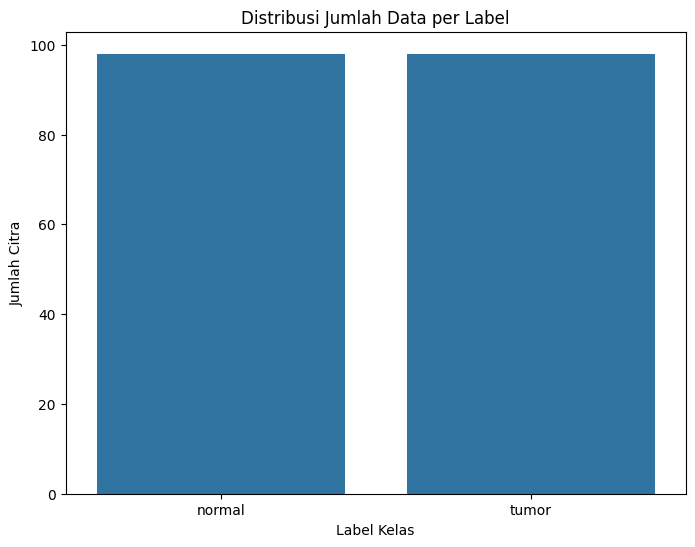

Jumlah kelas unik: 2

Jumlah citra per kelas:
normal    98
tumor     98
Name: count, dtype: int64


In [56]:
# Mengubah list labels menjadi pandas Series untuk memudahkan penghitungan
label_series = pd.Series(labels)

# Menghitung jumlah kemunculan setiap label
label_counts = label_series.value_counts()

# Membuat diagram batang
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribusi Jumlah Data per Label')
plt.xlabel('Label Kelas')
plt.ylabel('Jumlah Citra')
plt.show()

# Menampilkan informasi dataset
print(f"Jumlah kelas unik: {len(label_counts)}")
print("\nJumlah citra per kelas:")
print(label_counts)

## Preprocessing Citra Baseline

Tahap pra-proses ini diawali dengan pembuatan sebuah fungsi kustom bernama `baseline(img)` untuk melakukan standardisasi pada setiap matriks citra yang masuk. Di dalam fungsi ini, terdapat pemeriksaan kondisi menggunakan `len(img.shape) == 3` untuk mendeteksi apakah citra input masih bertipe multi-kanal seperti RGB atau BGR. Jika kondisi tersebut terpenuhi, fungsi `cv.cvtColor(img, cv.COLOR_BGR2GRAY)` dari OpenCV langsung dijalankan untuk mengonversi moda warna gambar menjadi skala abu-abu (*grayscale*). Setelah dipastikan berada dalam format satu kanal, dimensi geometris citra diubah secara seragam menjadi resolusi 128x128 piksel menggunakan perintah `cv.resize`. Proses penyesuaian ukuran dan warna ini diakhiri dengan mengembalikan matriks citra yang telah dimodifikasi melalui instruksi `return img`.

Langkah selanjutnya adalah menerapkan fungsi standardisasi tersebut ke seluruh koleksi data gambar yang tersedia. Eksekusi ini memanfaatkan mekanisme *list comprehension* melalui baris kode `dataPreprocessed = [baseline(img) for img in data]`. Perintah ini secara iteratif mengambil setiap elemen gambar dari variabel `data`, melewatkannya ke dalam fungsi `baseline`, dan menghimpun kembali seluruh hasilnya ke dalam sebuah variabel baru bernama `dataPreprocessed`, sehingga dataset kini berada dalam kondisi siap untuk proses ekstraksi fitur atau pemodelan.

In [57]:
def baseline(img):
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = cv.resize(img, (128, 128))
    return img

# apply ke semua data
dataPreprocessed = [baseline(img) for img in data]

## Tampilkan Sampel Citra Dataset

Tahap visualisasi ini diawali dengan mengisolasi indeks posisi data berdasarkan kategori masing-masing kelompok kelas. Menggunakan mekanisme *list comprehension* dan fungsi `enumerate(labels)`, sistem memindai seluruh label data dan menyaring indeksnya ke dalam variabel `normal_indx` untuk kategori normal serta `tumor_indx` untuk kategori tumor. Guna membatasi jumlah data yang akan ditampilkan agar tidak membebani memori, dilakukan pemotongan array menggunakan operasi *slicing* `[:90]` sehingga setiap kelompok kelas hanya diambil maksimal 90 sampel pertama saja.

Langkah berikutnya adalah pendefinisian fungsi kustom `show_images(idxs, title)` untuk menyusun tata letak penampilan gambar ke dalam bentuk grid atau matriks visual. Fungsi ini menyiapkan sebuah kanvas berukuran 15x12 inci yang dibagi menjadi sub-plot berstruktur 9 baris dan 10 kolom melalui perintah `plt.subplots(9, 10)`. Di dalam fungsi tersebut, sebuah perulangan (*for*) digunakan untuk menelusuri setiap indeks gambar yang masuk. Posisi baris dan kolom dari setiap gambar ditentukan secara matematis menggunakan operasi pembagian bilangan bulat (`k // 10`) dan sisa pembagian (`k % 10`). Gambar dari variabel `dataPreprocessed` kemudian diproyeksikan ke sub-plot terkait dengan peta warna skala abu-abu (`cmap='gray'`), dibarengi dengan penghilangan garis tepi koordinat via perintah `axis('off')`.

Prosedur visualisasi ini diakhiri dengan mekanisme pembersihan untuk mengantisipasi adanya sisa sub-plot yang kosong. Melalui perulangan kedua, setiap posisi plot dari jumlah gambar yang tersedia hingga batas maksimal 90 akan dinonaktifkan sumbu koordinatnya agar tampilan grid tetap rapi dan konsisten. Pengaturan jarak antar gambar dioptimalkan secara otomatis menggunakan `plt.tight_layout()` sebelum grafik akhirnya diproyeksikan ke layar lewat instruksi `plt.show()`. Fungsi kustom ini kemudian dieksekusi dua kali di bagian akhir kode untuk menampilkan kumpulan citra dari kelas "Normal" dan kelas "Tumor" secara terpisah.

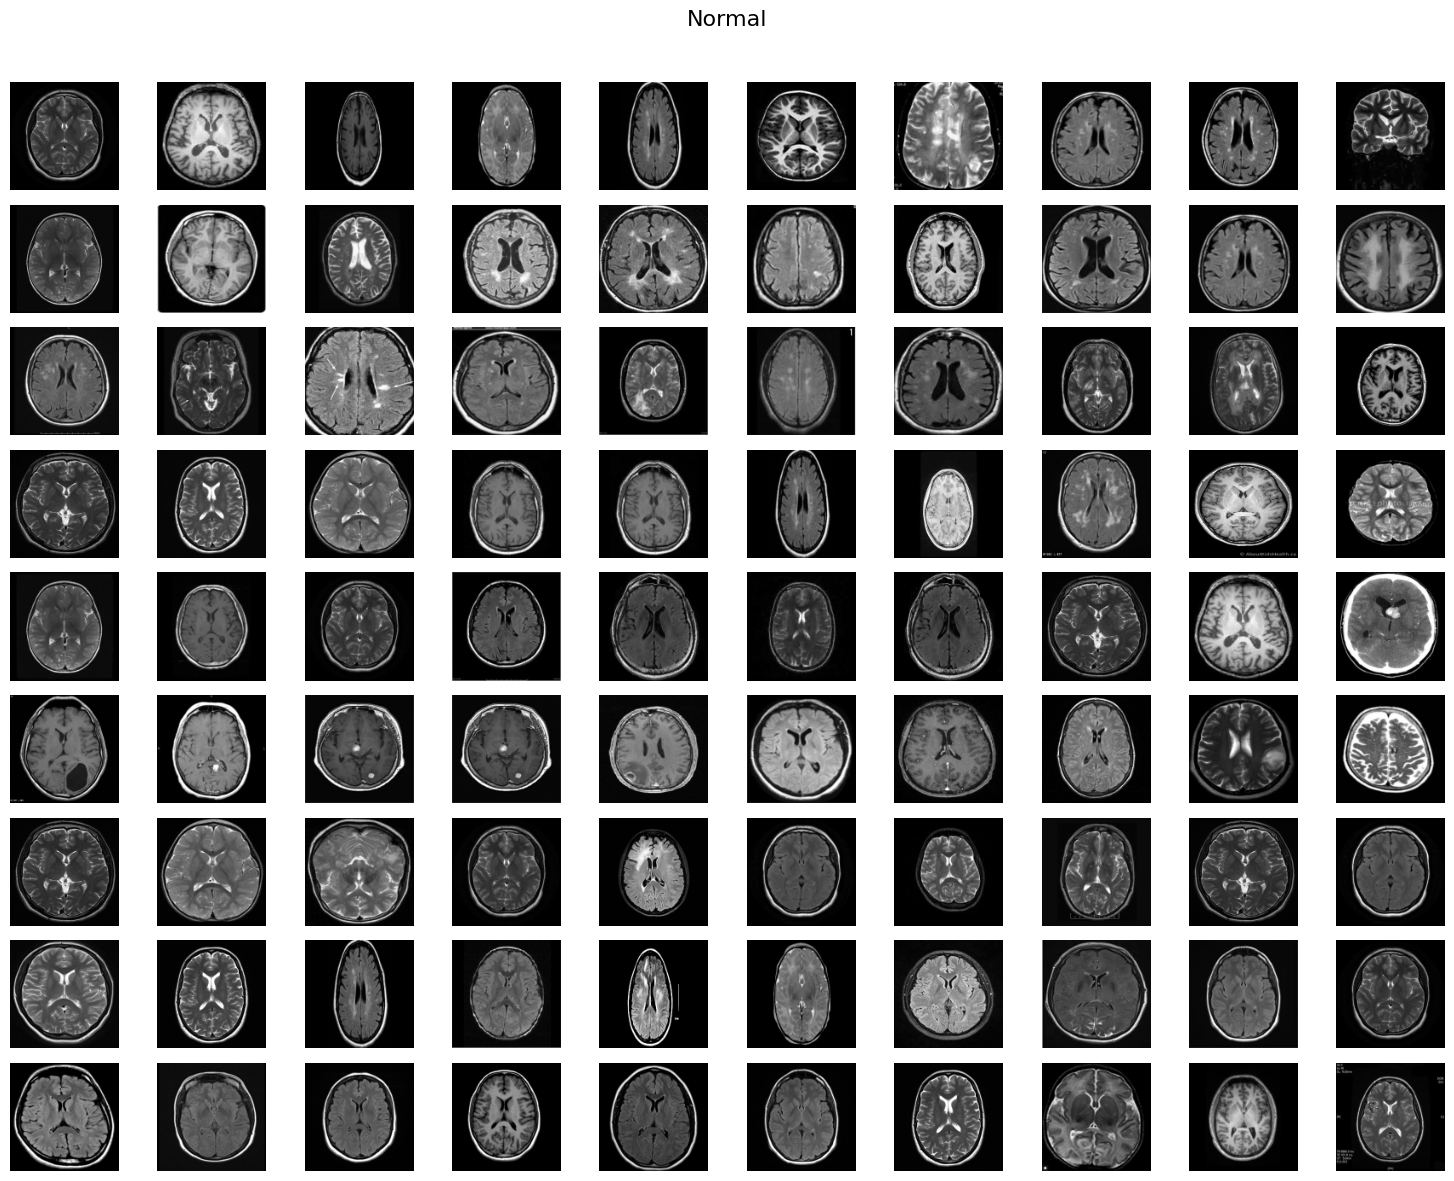

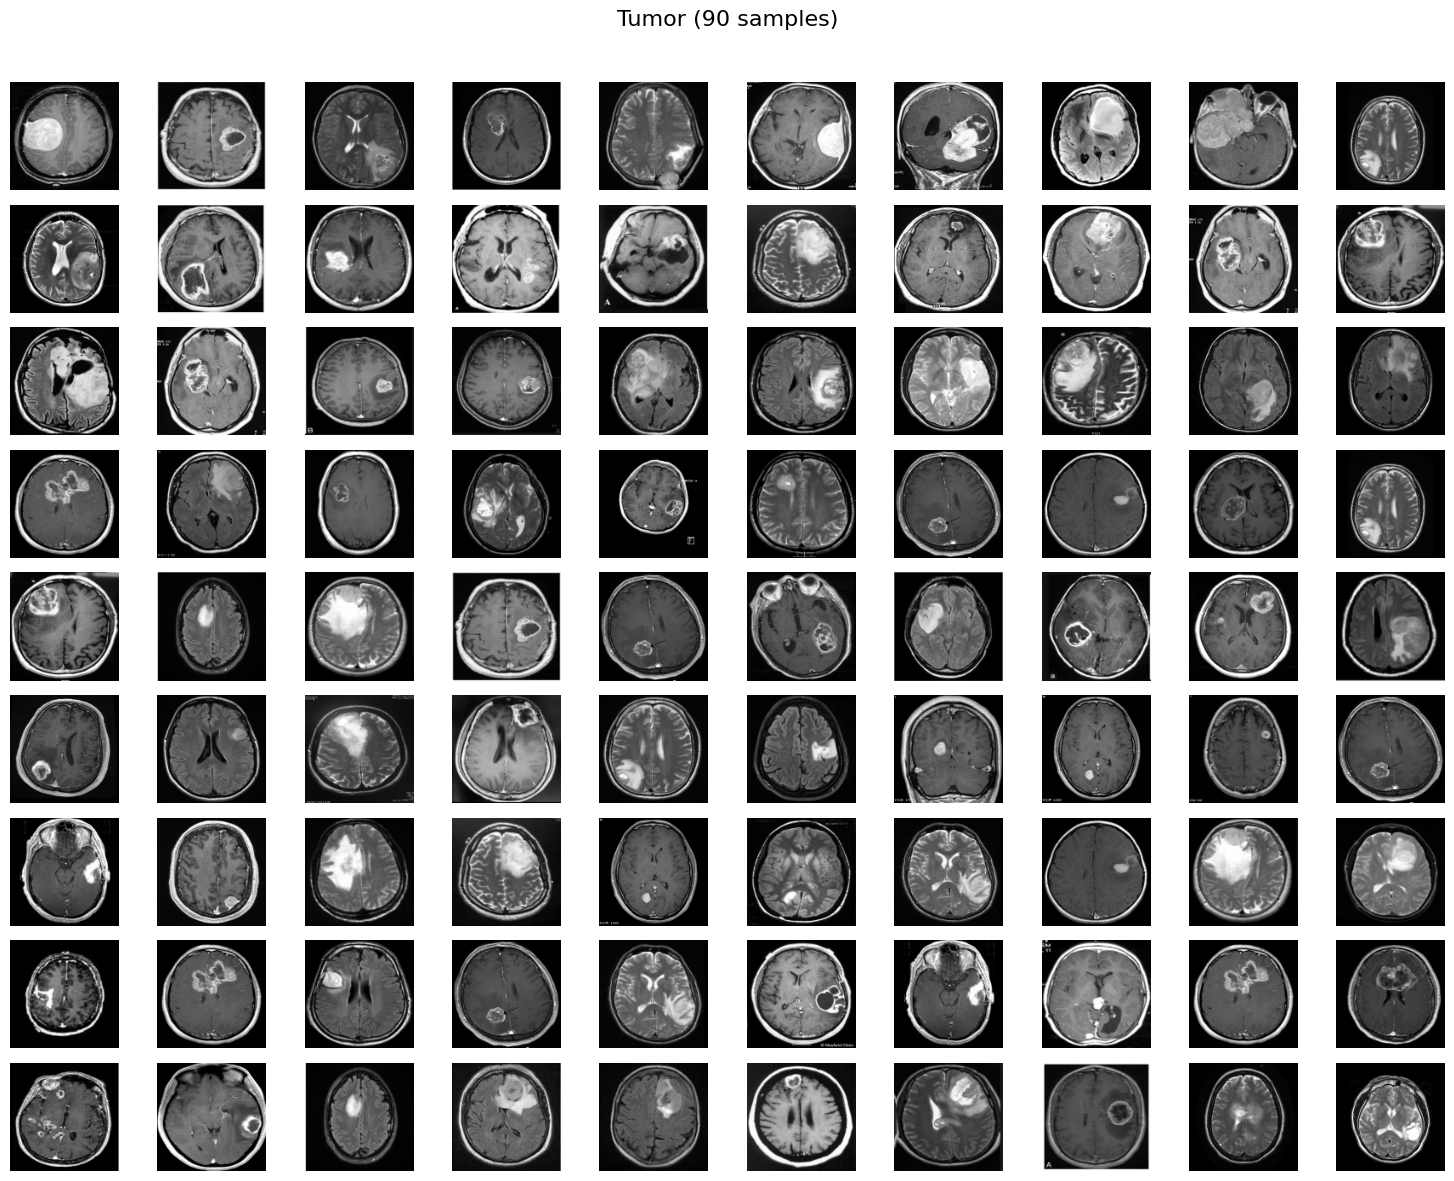

In [58]:
# ambil index berdasarkan label
normal_indx = [i for i, l in enumerate(labels) if l.lower() == "normal"]
tumor_indx = [i for i, l in enumerate(labels) if l.lower() == "tumor"]

# ambil maksimal 90
normal_indx = normal_indx[:90]
tumor_indx = tumor_indx[:90]


def show_images(idxs, title):
    fig, axs = plt.subplots(9, 10, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    for k in range(len(idxs)):
        row = k // 10
        col = k % 10
        axs[row][col].imshow(dataPreprocessed[idxs[k]], cmap='gray')
        axs[row][col].axis('off')

    # matikan subplot kosong
    for k in range(len(idxs), 90):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# tampilkan
show_images(normal_indx, "Normal")
show_images(tumor_indx, "Tumor (90 samples)")

### Feature Extraction

Karakteristik tekstur dari gambar hasil pra-proses diekstrak dengan membangun fungsi kustom bernama `glcm`. Pembuatan fungsi ini mengandalkan pendekatan *Gray Level Co-occurrence Matrix* (GLCM) untuk memetakan hubungan spasial antar piksel tetangga lewat analisis tingkat kecerahannya. Informasi spasial yang diperoleh dari matriks inilah yang kemudian dijadikan fondasi utama dalam menghitung parameter fitur tekstur pada tahapan berikutnya.

Proses analisis mencakup variasi orientasi sudut yang meliputi 0°, 45°, 90°, dan 135°. Setiap nilai derajat tersebut dikonversi secara otomatis ke format radian agar selaras dengan kebutuhan komputasi pustaka. Penjelajahan multi-sudut ini diterapkan demi memastikan bahwa orientasi tekstur yang beragam di dalam gambar dapat terekam secara utuh, mengingat pola sebaran visual pada citra medis atau objek natural sering kali tidak searah.

Konfigurasi pembentukan matriks menggunakan parameter jarak antar-piksel bernilai 1 serta rentang kuantisasi keabuan maksimal sebesar 256 tingkatan. Pengaktifan opsi `symmetric=True` membuat perhitungan relasi ketetanggaaan piksel dilakukan secara timbal balik (dua arah), sementara pengaturan `normed=True` mengubah nilai kemunculan menjadi skala probabilitas agar datanya lebih seragam. Hasil akhir dari fungsi ini berupa matriks GLCM ternormalisasi yang siap dikirim sebagai input bagi algoritma klasifikasi.

In [59]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

## Ekstraksi Properti Fitur Tekstur GLCM

Tahapan kalkulasi fitur ini diimplementasikan melalui pembuatan serangkaian fungsi kustom untuk mengekstrak karakteristik statistik spesifik dari matriks GLCM yang telah dinormalisasi. Pustaka Scikit-Image dimanfaatkan lewat fungsi `graycoprops` untuk mengambil properti tekstur utama secara individual. Setiap nilai properti yang dihasilkan kemudian diisolasi pada indeks koordinat `[0, 0]` guna mengambil nilai skalar tunggal dari matriks tersebut.

Rincian parameter tekstur yang diekstrak meliputi aspek-aspek berikut:

- **Korelasi (correlation)**: Mengukur tingkat ketergantungan linear nilai keabuan antar piksel tetangga.
- **Ketidakmiripan (dissimilarity)**: Menghitung variasi atau jarak linear perbedaan intensitas piksel di dalam citra.
- **Homogenitas (homogeneity)**: Mengukur tingkat kerapatan atau keseragaman distribusi variasi tekstur pada citra.
- **Kontras (contrast)**: Menghitung intensitas kontras lokal yang merepresentasikan perbedaan tingkat ketajaman antara piksel terang dan gelap.
- **ASM (Angular Second Moment)**: Mengukur tingkat keseragaman piksel yang menjadi indikator keteraturan pola tekstur.
- **Energi (energy)**: Akar kuadrat dari nilai ASM yang memberikan representasi kekuatan atau dominasi tekstur tertentu.

Sebagai tambahan, kalkulasi tekstur dilengkapi dengan fungsi `entropyGlcm(matriks)` untuk mengukur tingkat keacakan atau kompleksitas informasi di dalam gambar. Berbeda dari parameter sebelumnya, perhitungan ini memanfaatkan modul entropy dari SciPy. Sebelum nilai entropi dihitung, dimensi matriks kookurensi diubah terlebih dahulu menjadi struktur larik satu dimensi menggunakan perintah `matriks.ravel()`, sehingga seluruh nilai probabilitas dapat diproses secara menyeluruh untuk menghasilkan representasi fitur tekstur yang komprehensif.

In [60]:
def correlation(matriks):
  	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Ekstraksi Matriks GLCM Multi-Sudut

Tahap komputasi ini dilaksanakan untuk membangun matriks kookurensi dari seluruh dataset citra secara spesifik pada empat arah orientasi yang berbeda. Langkah awal diwujudkan dengan mendeklarasikan empat buah *list* kosong, masing-masing bernama `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135`. Keempat larik data ini dipersiapkan sebagai struktur penyimpanan terpisah untuk mengelompokkan hasil kalkulasi matriks GLCM berdasarkan sudut pengamatannya.

Proses ekstraksi dilakukan secara menyeluruh dengan memanfaatkan perulangan *for* yang menelusuri indeks setiap gambar di dalam variabel `dataPreprocessed`. Pada tiap iterasi, gambar hasil pra-proses diumpankan ke dalam fungsi kustom `glcm` sebanyak empat kali dengan menyertakan parameter sudut orientasi secara bergantian, yaitu 0°, 45°, 90°, dan 135°. Hasil perhitungan dari masing-masing sudut tersebut berturut-turut ditampung ke dalam variabel sementara `D0`, `D45`, `D90`, dan `D135`.

Siklus iterasi untuk satu gambar tersebut diakhiri dengan memasukkan setiap matriks fitur yang terbentuk ke dalam *list* tampungan yang bersesuaian menggunakan perintah `append`. Melalui mekanisme ini, data spasial tekstur citra berhasil dipecah secara terstruktur berdasarkan variasi sudut pandangnya, sehingga menyediakan representasi fitur yang kaya dan siap ditransformasikan ke dalam parameter statistik untuk kebutuhan pemodelan *machine learning*.

In [61]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)


## Inisialisasi Larik Fitur Statistik GLCM Multi-Sudut

Tahap ini melibatkan penyiapan struktur penyimpanan data sebelum dilakukannya proses ekstraksi nilai statistik dari matriks GLCM. Proses deklarasi variabel dilakukan secara serentak dengan mengalokasikan puluhan *list* kosong yang dikelompokkan berdasarkan jenis parameter tekstur serta orientasi sudut pengamatannya, yaitu 0°, 45°, 90°, dan 135°. Penataan matriks tampungan yang terpisah sejak awal ini sangat penting guna mengorganisasi nilai fitur skalar yang akan dihitung dari setiap gambar secara terstruktur.

Struktur alokasi memori ini mencakup tujuh properti tekstur utama dataset:
- **Kontras** (`Kontras0` hingga `Kontras135`): Larik penampung tingkat ketajaman atau perbedaan intensitas lokal antar-piksel.
- **Ketidakmiripan** (`dissimilarity0` hingga `dissimilarity135`): Tempat penyimpanan nilai variasi linear perbedaan derajat keabuan.
- **Homogenitas** (`homogeneity0` hingga `homogeneity135`): Wadah untuk mengumpulkan nilai keseragaman distribusi spasial piksel.
- **Entropi** (`entropy0` hingga `entropy135`): Struktur penyimpanan tingkat keacakan informasi tekstur.
- **ASM** (`ASM0` hingga `ASM135`): Barisan variabel penampung keteraturan pola spasial citra.
- **Energi** (`energy0` hingga `energy135`): Struktur data untuk menyimpan representasi kekuatan tekstur.
- **Korelasi** (`correlation0` hingga `correlation135`): Matriks tampungan nilai ketergantungan linear aras keabuan.

Langkah inisialisasi ini menjadi fondasi yang valid sebelum sistem menjalankan perulangan ekstraksi fitur. Dengan memisahkan setiap parameter ke dalam kombinasi nama properti dan sudut derajat yang spesifik, seluruh fitur statistik yang berhasil terekstrak nantinya dapat langsung dipetakan ke dalam kolom-kolom data yang rapi dan siap ditransformasikan menjadi objek DataFrame.

In [62]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

## Ekstraksi Fitur Correlation Multi-Sudut

Proses iterasi ini diterapkan untuk menghitung nilai statistik korelasi dari seluruh matriks kookurensi yang telah terdistribusi berdasarkan orientasi sudutnya. Menggunakan perulangan *for* sepanjang total baris dataset `dataPreprocessed`, sistem mengekstrak parameter ketergantungan linier nilai keabuan dari empat arah sudut, yaitu 0°, 45°, 90°, dan 135°.

Di dalam perulangan, fungsi kustom `correlation` dipanggil secara berkala dengan parameter masukan berupa matriks GLCM yang diambil dari daftar `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135` sesuai indeks data saat itu. Hasil kalkulasi skalar yang diperoleh ditampung ke dalam variabel lokal `C0` hingga `C135`, kemudian langsung dimasukkan ke dalam masing-masing *list* tujuan (`correlation0` sampai `correlation135`) lewat perintah `append` agar siap dikonversi ke struktur tabular.

In [63]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

## Ekstraksi Fitur Kontras Multi-Sudut

Proses iterasi ini diterapkan untuk mengalkulasi parameter statistik kontras dari seluruh matriks kookurensi yang telah terdistribusi berdasarkan orientasi sudutnya. Menggunakan perulangan *for* sepanjang total baris dataset data, sistem mengekstrak nilai perbedaan intensitas lokal dari empat arah sudut, yaitu 0°, 45°, 90°, dan 135°.

Di dalam perulangan, fungsi kustom `contrast` dipanggil secara berkala dengan parameter masukan berupa matriks GLCM yang diambil dari daftar `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135` sesuai indeks data saat itu. Hasil kalkulasi skalar yang diperoleh ditampung ke dalam variabel lokal `K0` hingga `K135`, kemudian langsung dimasukkan ke dalam masing-masing *list* tujuan (`Kontras0` sampai `Kontras135`) lewat perintah `append` agar siap dikonversi ke struktur tabular.

In [64]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

## Ekstraksi Fitur Dissimilarity Multi-Sudut

Proses iterasi ini diterapkan untuk mengalkulasi nilai statistik ketidakmiripan (*dissimilarity*) dari seluruh matriks kookurensi yang telah terdistribusi berdasarkan orientasi sudutnya. Menggunakan perulangan *for* sepanjang total data pada variabel `data`, sistem mengekstrak parameter perbedaan linear intensitas derajat keabuan dari empat arah sudut, yaitu 0°, 45°, 90°, dan 135°.

Di dalam perulangan, fungsi kustom `dissimilarity` dipanggil secara berkala dengan menyertakan matriks GLCM dari daftar `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135` sesuai dengan indeks posisi data saat itu. Hasil perhitungan skalar yang didapat ditampung ke dalam variabel lokal `Dis0` hingga `Dis135`, lalu dimasukkan ke dalam masing-masing *list* tujuan (`dissimilarity0` sampai `dissimilarity135`) menggunakan perintah `append` agar siap ditransformasikan ke dalam format data tabular.

In [65]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

## Ekstraksi Fitur Homogeneity Multi-Sudut

Proses iterasi ini diterapkan untuk mengalkulasi nilai statistik homogenitas (*homogeneity*) dari seluruh matriks kookurensi yang telah terdistribusi berdasarkan orientasi sudutnya. Menggunakan perulangan *for* sepanjang total baris dataset pada variabel `data`, sistem mengekstrak parameter keseragaman distribusi variasi tekstur dari empat arah sudut, yaitu 0°, 45°, 90°, dan 135°.

Di dalam perulangan, fungsi kustom `homogeneity` dipanggil secara berkala dengan parameter masukan berupa matriks GLCM yang diambil dari daftar `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135` sesuai indeks data saat itu. Hasil kalkulasi skalar yang diperoleh ditampung ke dalam variabel lokal `H0` hingga `H135`, kemudian langsung dimasukkan ke dalam masing-masing *list* tujuan (`homogeneity0` sampai `homogeneity135`) lewat perintah `append` agar siap dikonversi ke struktur data tabular.

In [66]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

## Ekstraksi Fitur Entropy Multi-Sudut

Proses iterasi ini diterapkan untuk mengalkulasi nilai statistik entropi dari seluruh matriks kookurensi yang telah terdistribusi berdasarkan orientasi sudutnya. Menggunakan perulangan *for* sepanjang total data pada variabel `data`, sistem mengekstrak parameter keacakan informasi tekstur dari empat arah sudut, yaitu 0°, 45°, 90°, dan 135°.

Di dalam perulangan, fungsi kustom `entropyGlcm` dipanggil secara berkala dengan menyertakan matriks GLCM dari daftar `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135` sesuai dengan indeks posisi data saat itu. Hasil perhitungan skalar yang didapat ditampung ke dalam variabel lokal `E0` hingga `E135`, kemudian langsung dimasukkan ke dalam masing-masing *list* tujuan (`entropy0` sampai `entropy135`) menggunakan perintah `append` agar siap ditransformasikan ke dalam format data tabular.

In [67]:
for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

## Ekstraksi Fitur ASM Multi-Sudut

Proses iterasi ini diterapkan untuk mengalkulasi nilai statistik *Angular Second Moment* (ASM) dari seluruh matriks kookurensi yang telah terdistribusi berdasarkan orientasi sudutnya. Menggunakan perulangan *for* sepanjang total baris dataset pada variabel `data`, sistem mengekstrak parameter tingkat keseragaman piksel dari empat arah sudut, yaitu 0°, 45°, 90°, dan 135°.

Di dalam perulangan, fungsi kustom `ASM` dipanggil secara berkala dengan menyertakan parameter masukan berupa matriks GLCM yang diambil dari daftar `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135` sesuai indeks data saat itu. Hasil kalkulasi skalar yang diperoleh ditampung ke dalam variabel lokal `A0` hingga `A135`, kemudian langsung dimasukkan ke dalam masing-masing *list* tujuan (`ASM0` sampai `ASM135`) lewat perintah `append` agar siap ditransformasikan ke dalam struktur data tabular.

In [68]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

## Ekstrak Fitur Energy Multi-Sudut

Proses iterasi ini diterapkan untuk mengalkulasi nilai statistik energi (*energy*) dari seluruh matriks kookurensi yang telah terdistribusi berdasarkan orientasi sudutnya. Menggunakan perulangan *for* sepanjang total baris dataset pada variabel `data`, sistem mengekstrak parameter kekuatan atau dominasi tekstur dari empat arah sudut, yaitu 0°, 45°, 90°, dan 135°.

Di dalam perulangan, fungsi kustom `energy` dipanggil secara berkala dengan parameter masukan berupa matriks GLCM yang diambil dari daftar `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135` sesuai indeks data saat itu. Hasil kalkulasi skalar yang diperoleh ditampung ke dalam variabel lokal `ER0` hingga `ER135`, kemudian langsung dimasukkan ke dalam masing-masing *list* tujuan (`energy0` sampai `energy135`) lewat perintah `append` agar siap ditransformasikan ke dalam struktur data tabular.

In [69]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

## Penggabungan Fitur GLCM Multi-Sudut ke dalam DataFrame

Tahap akhir dari ekstraksi karakteristik tekstur ini melibatkan pengumpulan seluruh parameter statistik yang telah dihitung ke dalam satu struktur matriks yang terorganisasi. Sebuah perulangan *for* dijalankan untuk menelusuri setiap indeks citra di dalam dataset `dataPreprocessed`. Pada setiap iterasi, nilai dari tujuh properti tekstur—kontras, ketidakmiripan, homogenitas, entropi, ASM, energi, dan korelasi—diambil dari empat sudut orientasi (0°, 45°, 90°, dan 135°) lalu dihimpun secara berurutan ke dalam sebuah *list* multidimensi bernama `fitur`.

Kumpulan larik fitur dari setiap gambar tersebut secara bertahap dimasukkan ke dalam variabel penampung utama bernama `features` via perintah `append`. Setelah siklus perulangan selesai memproses seluruh gambar, struktur data mentah tersebut dikonversi menjadi format tabular menggunakan pustaka Pandas lewat instruksi `pd.DataFrame(features, columns=columns)`. Komponen susunan kolom (`columns`) didefinisikan secara eksplisit untuk memberikan penamaan yang spesifik pada setiap kombinasi fitur dan sudutnya (seperti `"contrast_0"` hingga `"correlation_155"`), sehingga menghasilkan objek DataFrame bernama `df_fitur` yang rapi dan siap digunakan untuk pemodelan *machine learning*.

In [70]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

## Pengorganisasian Fitur ke CSV dan Pembuatan DataFrame Baseline

Tahap penyelesaian ekstraksi ini berfokus pada integrasi seluruh larik fitur statistik yang telah dihitung ke dalam satu struktur tabel yang utuh. Proses diawali dengan menyusun sebuah kamus data (*dictionary*) bernama `dataTable`. Di dalam kamus ini, nama berkas asli (`'Filename'`) dan informasi kelas objek (`'Label'`) dipetakan bersama dengan ke-28 kombinasi fitur statistik GLCM yang mencakup kontras, homogenitas, ketidakmiripan, entropi, ASM, energi, serta korelasi dari masing-masing sudut orientasi (0°, 45°, 90°, dan 135°).

Setelah struktur data mentah berhasil diorganisasi di dalam kamus, objek tersebut langsung ditransformasikan menjadi representasi tabel menggunakan fungsi `pd.DataFrame(dataTable)` dan disimpan ke dalam variabel `df`. Data tabular baseline ini kemudian diekspor ke dalam penyimpanan lokal menjadi berkas dokumen berekstensi CSV dengan nama `'hasil_ekstrak_baseline.csv'` melalui perintah `df.to_csv` dengan menonaktifkan pencatatan indeks bawaan (`index=False`). Sebagai langkah verifikasi akhir, berkas CSV tersebut dimuat kembali ke dalam memori komputer via instruksi `pd.read_csv`, disimpan ke variabel `hasilEkstrak`, dan diproyeksikan langsung ke layar guna memastikan seluruh data tekstur dataset telah tersusun secara valid.

In [71]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_baseline.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_baseline.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1 no.jpeg,normal,296.029281,463.843884,265.992372,470.407589,0.445117,0.422199,0.455595,0.420137,...,0.052837,0.048164,0.229585,0.219212,0.229863,0.219464,0.880797,0.813621,0.892892,0.810983
1,10 no.jpg,normal,121.094919,204.082460,105.381090,202.514601,0.369847,0.327008,0.372664,0.330416,...,0.046737,0.042422,0.214811,0.205676,0.216187,0.205966,0.961494,0.934904,0.966497,0.935405
2,11 no.jpg,normal,480.232160,582.150784,166.802411,565.291587,0.708494,0.699807,0.737145,0.700218,...,0.438370,0.428559,0.658878,0.653969,0.662095,0.654644,0.818744,0.781559,0.937044,0.787885
3,12 no.jpg,normal,329.884719,429.666687,165.836983,410.766942,0.608607,0.596211,0.631248,0.594606,...,0.292216,0.283320,0.536811,0.532221,0.540570,0.532278,0.938436,0.920072,0.969053,0.923587
4,13 no.jpg,normal,681.151083,797.612127,202.169291,797.055862,0.587385,0.583835,0.640628,0.583791,...,0.177996,0.162635,0.404274,0.403368,0.421896,0.403281,0.845466,0.819138,0.953953,0.819265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Y95.jpg,tumor,261.362697,379.033232,236.341658,401.811272,0.501766,0.452430,0.516374,0.453442,...,0.063003,0.055337,0.250507,0.235887,0.251003,0.235239,0.933623,0.904190,0.939978,0.898432
192,Y96.jpg,tumor,471.107406,724.433133,397.094857,694.501333,0.464327,0.439189,0.467655,0.438084,...,0.116474,0.110382,0.341521,0.332060,0.341283,0.332238,0.859188,0.783542,0.881307,0.792486
193,Y97.JPG,tumor,192.315637,351.086180,199.053273,381.855540,0.233675,0.175058,0.229586,0.169180,...,0.001195,0.000949,0.035051,0.031162,0.034570,0.030798,0.967445,0.941028,0.966565,0.935859
194,Y98.JPG,tumor,272.200726,618.738793,429.425197,627.050778,0.387385,0.347244,0.405384,0.346105,...,0.055484,0.051505,0.235942,0.226874,0.235550,0.226948,0.934845,0.851037,0.896514,0.849039


## Seleksi Fitur Berbasis Korelasi dan Visualisasi Heatmap

Tahap reduksi dimensi ini dilakukan untuk mengeliminasi fitur tekstur yang memiliki multikolinieritas tinggi. Proses diawali dengan menghitung matriks korelasi linier melalui fungsi `.corr()` pada variabel `hasilEkstrak` setelah mengeluarkan kolom non-numerik (`Label` dan `Filename`). Angka pembatas dikonfigurasi pada variabel `threshold = 0.95` untuk menyaring pasangan fitur yang terlalu identik.

Melalui perulangan *for* bersarang, setiap elemen matriks korelasi diperiksa secara sistematis. Jika ditemukan pasangan fitur dengan nilai korelasi mencapai atau melewati angka 0.95, fitur ke-j akan ditandai untuk dihapus dengan mengubah nilai status menjadi `False`. Kolom yang lolos seleksi kemudian disimpan ke dalam variabel data baru bernama `x_new`, sementara target kelas dipisahkan ke variabel `y`.

Proses diakhiri dengan pembuatan kanvas grafik berukuran 17x17 inci melalui `plt.figure`. Pustaka Seaborn digunakan untuk memproyeksikan matriks korelasi fitur terpilih ke dalam bentuk peta panas (*heatmap*) lewat perintah `sns.heatmap`. Visualisasi ini dikonfigurasi dengan menampilkan angka koefisien secara eksplisit (`annot=True`), menggunakan gradasi warna biru (`cmap='Blues'`), serta memformat pembulatan dua angka di belakang koma (`fmt=".2f"`).

<Axes: >

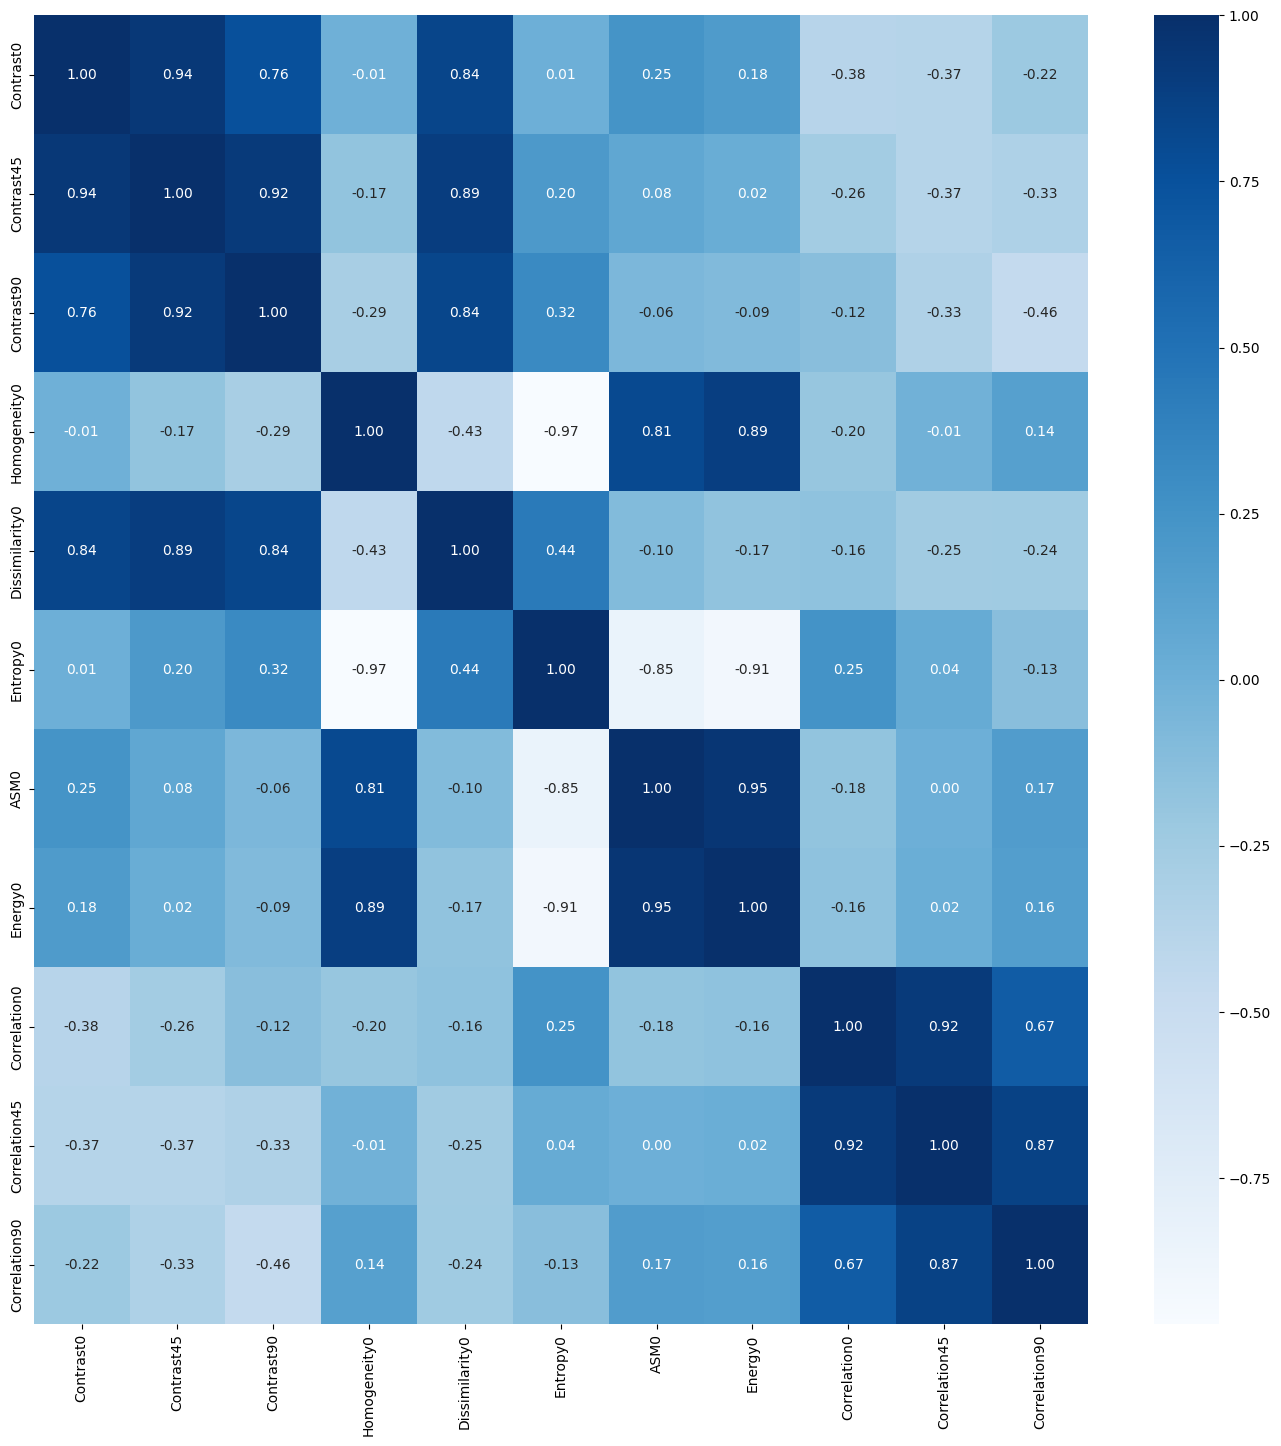

In [72]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Splitting Data

Kode ini melakukan pembagian dataset fitur (`x_new`) dan label (`y`) menjadi data pelatihan (train) dan pengujian (test) menggunakan fungsi `train_test_split` dari scikit-learn. Parameter `test_size=0.3` menunjukkan bahwa 30% data dialokasikan untuk testing, sedangkan 70% sisanya untuk training. Pengaturan `random_state=42` digunakan agar pembagian data ini konsisten dan dapat direproduksi. Setelah pembagian, kode mencetak bentuk (shape) dari dataset train dan test untuk memastikan proporsi pembagian data sudah sesuai yang diharapkan.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(137, 11)
(59, 11)
(137,)
(59,)


# Feature Normalization

## Normalisasi Data dengan Mean dan Standar Deviasi

Kode berikut ini melakukan normalisasi data menggunakan mean dan standar deviasi dari set pelatihan (`X_train`). Normalisasi ini bertujuan untuk menjadikan data memiliki mean nol dan standar deviasi satu, yang dapat meningkatkan kinerja dan kestabilan model machine learning tertentu.

In [74]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

# Modeling

## Define Model

Fungsi `generateClassificationReport(y_true, y_pred)` dibuat untuk menampilkan metrik evaluasi hasil prediksi klasifikasi, meliputi classification report (precision, recall, f1-score), confusion matrix, beserta nilai akurasi. Pada bagian berikutnya, diinisialisasi tiga model klasifikasi, yaitu `RandomForestClassifier` dengan konfigurasi 5 pohon keputusan, `SVC` (Support Vector Machine) dengan implementasi kernel RBF, serta `KNeighborsClassifier` dengan acuan 5 tetangga terdekat. Seluruh model tersebut kini siap digunakan untuk proses training dan evaluasi performa.

In [75]:
def generateClassificationReport(y_true, y_pred):
  print(classification_report(y_true, y_pred))
  print(confusion_matrix(y_true, y_pred))
  print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# Training and Evaluation Random Forest Classifier

Proses diawali dengan melakukan pelatihan model menggunakan fungsi `rf.fit(X_train, y_train)` agar algoritma dapat mengenali pola pada data latih. Selanjutnya, pengujian dilakukan dalam dua skenario terpisah untuk melihat performa model secara objektif. Skenario pertama berfokus pada pembuatan prediksi dan evaluasi menggunakan data pelatihan melalui fungsi `rf.predict(X_train)` yang kemudian hasilnya langsung dicetak menggunakan fungsi utilitas `generateClassificationReport`. Langkah serupa kemudian diterapkan pada skenario kedua untuk mengevaluasi data pengujian (`X_test`), di mana hasil prediksi akhir diuji keandalannya terhadap label asli (`y_test`) guna memastikan akurasi model pada data baru.

In [76]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      normal       0.94      0.99      0.96        68
       tumor       0.98      0.94      0.96        69

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137

[[67  1]
 [ 4 65]]
Accuracy: 0.9635036496350365

------Testing Set------
              precision    recall  f1-score   support

      normal       0.64      0.77      0.70        30
       tumor       0.70      0.55      0.62        29

    accuracy                           0.66        59
   macro avg       0.67      0.66      0.66        59
weighted avg       0.67      0.66      0.66        59

[[23  7]
 [13 16]]
Accuracy: 0.6610169491525424


# Training and Evaluation Support Vector Machine (SVM) Classifier

Proses berikutnya dilakukan dengan melatih model menggunakan perintah `svm.fit(X_train, y_train)` agar algoritma dapat mempelajari karakteristik data latih secara optimal. Guna mengukur kemampuan klasifikasi yang dihasilkan, pengujian diimplementasikan ke dalam dua tahap evaluasi yang berbeda. Tahap awal mengevaluasi performa internal menggunakan data pelatihan lewat fungsi `svm.predict(X_train)` yang luarannya langsung dianalisis oleh fungsi `generateClassificationReport`. Langkah serupa kemudian diterapkan pada tahap kedua untuk menguji data pengujian (`X_test`), di mana hasil prediksi akhir dicocokkan dengan label target asli (`y_test`) untuk melihat sejauh mana model mampu menggeneralisasi data baru.

In [77]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      normal       0.81      0.71      0.76        68
       tumor       0.74      0.84      0.79        69

    accuracy                           0.77       137
   macro avg       0.78      0.77      0.77       137
weighted avg       0.78      0.77      0.77       137

[[48 20]
 [11 58]]
Accuracy: 0.7737226277372263

------Testing Set------
              precision    recall  f1-score   support

      normal       0.64      0.60      0.62        30
       tumor       0.61      0.66      0.63        29

    accuracy                           0.63        59
   macro avg       0.63      0.63      0.63        59
weighted avg       0.63      0.63      0.63        59

[[18 12]
 [10 19]]
Accuracy: 0.6271186440677966


# Training and Evaluation K-Nearest Neighbors (KNN) Classifier

Tahap akhir dari eksperimen klasifikasi ini dilakukan dengan melatih model melalui perintah `knn.fit(X_train, y_train)` agar algoritma dapat memetakan kedekatan jarak pada data latih. Untuk menguji keandalan hasil klasifikasi yang terbentuk, evaluasi dijalankan ke dalam dua skenario pengujian. Skenario pertama memanfaatkan fungsi `knn.predict(X_train)` guna menghasilkan prediksi pada data pelatihan, yang kemudian luarannya langsung dianalisis oleh fungsi `generateClassificationReport`. Pola evaluasi yang sama selanjutnya diterapkan pada skenario kedua untuk menguji data pengujian (`X_test`), di mana hasil prediksi akhir dikomparasikan langsung dengan label target asli (`y_test`) untuk memvalidasi performa model dalam mengenali data baru.

In [78]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      normal       0.78      0.75      0.77        68
       tumor       0.76      0.80      0.78        69

    accuracy                           0.77       137
   macro avg       0.77      0.77      0.77       137
weighted avg       0.77      0.77      0.77       137

[[51 17]
 [14 55]]
Accuracy: 0.7737226277372263

------Testing Set------
              precision    recall  f1-score   support

      normal       0.76      0.53      0.63        30
       tumor       0.63      0.83      0.72        29

    accuracy                           0.68        59
   macro avg       0.70      0.68      0.67        59
weighted avg       0.70      0.68      0.67        59

[[16 14]
 [ 5 24]]
Accuracy: 0.6779661016949152


# Evaluation With Confusion Matrix

Fungsi `plot_confusion_matrix` digunakan untuk menampilkan confusion matrix dari hasil prediksi model secara visual menggunakan `matplotlib`, dengan parameter judul yang ditampilkan di atas grafik. Selanjutnya, fungsi ini dipanggil untuk memvisualisasikan confusion matrix dari ketiga model klasifikasi (Random Forest, SVM, dan KNN) berdasarkan hasil prediksi terhadap data uji (`X_test`) guna mempermudah analisis kesalahan klasifikasi tiap model.

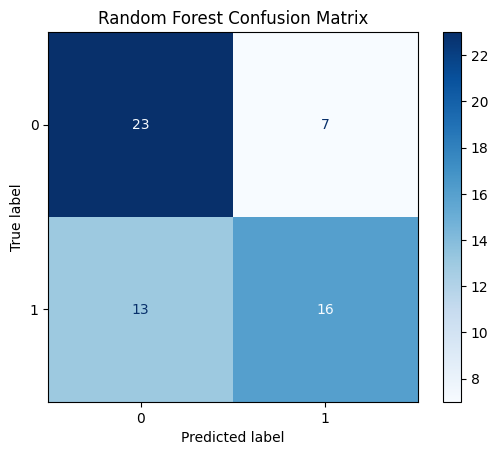

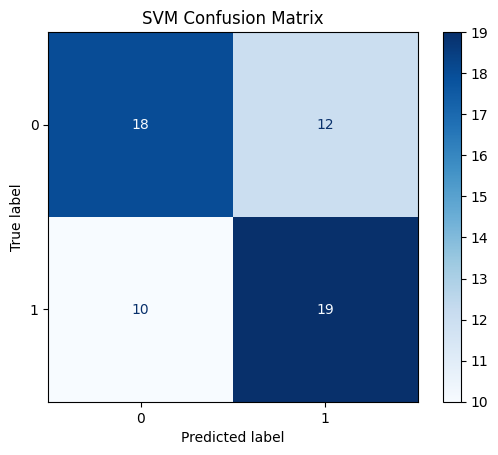

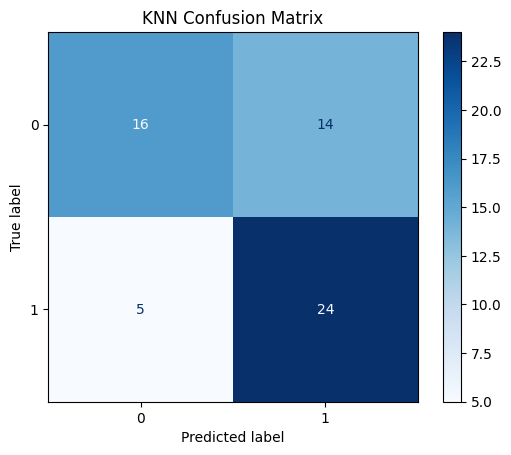

In [79]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")